In [3]:
import pandas as pd

In [5]:
dataset=pd.read_csv("Tatacoffee13_21.csv",parse_dates=['Date'],index_col="Date")
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [7]:
column="Close"

In [9]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(dataset[[column]])
print("Len:",data1.shape)

Len: (2225, 1)


In [10]:
round(len(data1)*0.80)

1780

In [11]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [15]:
from sklearn.metrics import root_mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

Lag=1,Trend=n
RMSE-Testset: 0.058859347313835804
maPe-Testset: 108221610722.61342
************
Lag=1,Trend=t
RMSE-Testset: 0.06567306536705884
maPe-Testset: 105694109653.12195
************
Lag=1,Trend=c
RMSE-Testset: 0.04336525033769232
maPe-Testset: 114804919729.42868
************
Lag=1,Trend=ct
RMSE-Testset: 0.15273694386313108
maPe-Testset: 74699776526.69624
************
Lag=2,Trend=n
RMSE-Testset: 0.059469572437784744
maPe-Testset: 107811149748.47498
************
Lag=2,Trend=t
RMSE-Testset: 0.05333387798235747
maPe-Testset: 110268940666.54283
************
Lag=2,Trend=c
RMSE-Testset: 0.03487154364938857
maPe-Testset: 119368707397.79979
************
Lag=2,Trend=ct
RMSE-Testset: 0.1514707786943344
maPe-Testset: 72770748055.74382
************
Lag=3,Trend=n
RMSE-Testset: 0.05944295500377167
maPe-Testset: 108331645493.58429
************
Lag=3,Trend=t
RMSE-Testset: 0.053497989920510955
maPe-Testset: 110722667896.75563
************
Lag=3,Trend=c
RMSE-Testset: 0.03603799252427597
maPe-Tests

In [19]:
len(y_pred)

445

In [31]:
i=2
td='c'
model=AutoReg(X_train,lags=i,trend=td)
model_fit=model.fit()
y_pred=model_fit.predict(len(X_train),len(data1)-1)
print("Lag={},Trend={}".format(i,td))
rmse=rmsemape(y_test,y_pred)

Lag=2,Trend=c
RMSE-Testset: 0.03487154364938857
maPe-Testset: 119368707397.79979


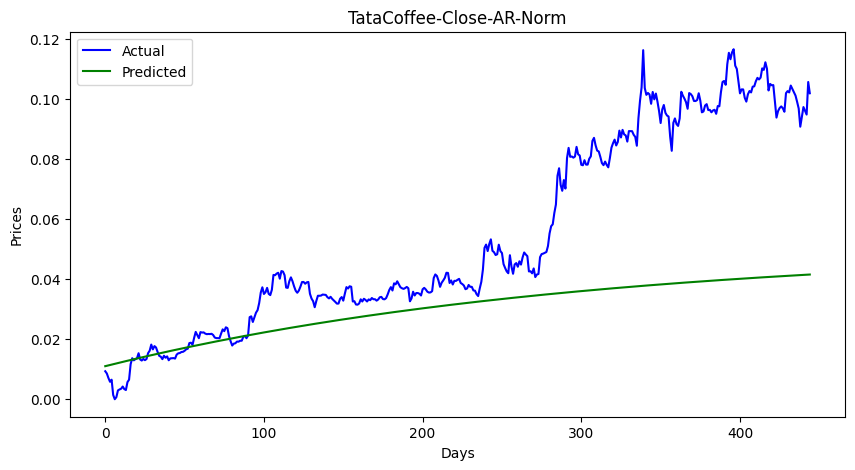

In [81]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [105]:
y_test

array([0.00931949, 0.00856893, 0.0070678 , 0.00581686, 0.00650488,
       0.00140731, 0.        , 0.00068802, 0.0029397 , 0.00325244,
       0.00350263, 0.00422192, 0.00337753, 0.0030648 , 0.00569177,
       0.00650488, 0.01169627, 0.0136665 , 0.01294721, 0.01335377,
       0.01363523, 0.01532399, 0.01322867, 0.01288466, 0.01341631,
       0.01300976, 0.01338504, 0.01535527, 0.01616838, 0.01820115,
       0.0166062 , 0.01770078, 0.01723167, 0.01573055, 0.01444834,
       0.01416688, 0.01335377, 0.01447961, 0.01382287, 0.0142607 ,
       0.01297848, 0.01360395, 0.01363523, 0.01369777, 0.01354141,
       0.01485489, 0.01529272, 0.01538654, 0.01573055, 0.01579309,
       0.0161371 , 0.01663748, 0.01682512, 0.01870153, 0.01882662,
       0.01810733, 0.02042157, 0.02242307, 0.02135977, 0.02032775,
       0.02236052, 0.02220415, 0.0222667 , 0.02186015, 0.0216725 ,
       0.02173505, 0.02170378, 0.0217976 , 0.02139104, 0.02054666,
       0.02035902, 0.02035902, 0.02032775, 0.02186015, 0.02326

In [121]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [123]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

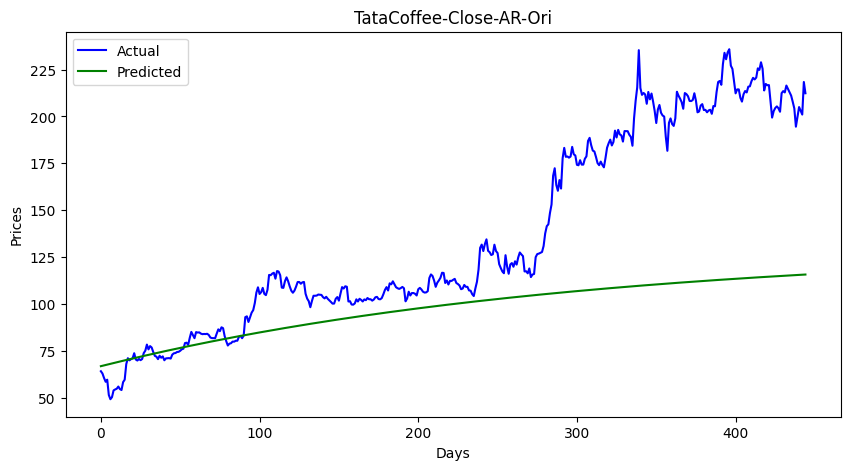

In [125]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [127]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 55.75262398664243
maPe-Testset: 0.23324146264728002


In [129]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [131]:
forecast

array([0.04156393, 0.04159358, 0.04162314, 0.0416526 ])

In [149]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [151]:
forecast_stock_price_test_oriF

,Closefore
0,115.852408
1,115.899822
2,115.947078
3,115.994175


In [153]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)